<a href="https://colab.research.google.com/github/Sayandt-web/-Atmospheric-Scattering-Model-Combined-With-Image-Segmentation-in-Foggy-Image-Enhancement-/blob/main/Atmospheric_Scattering_Model_Combined_With_Image_Segmentation_in_Foggy_Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atmospheric Scattering Model Combined
With Image Segmentation in Foggy
Image Enhancement
(QIAOLING LIU)

https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=10883994

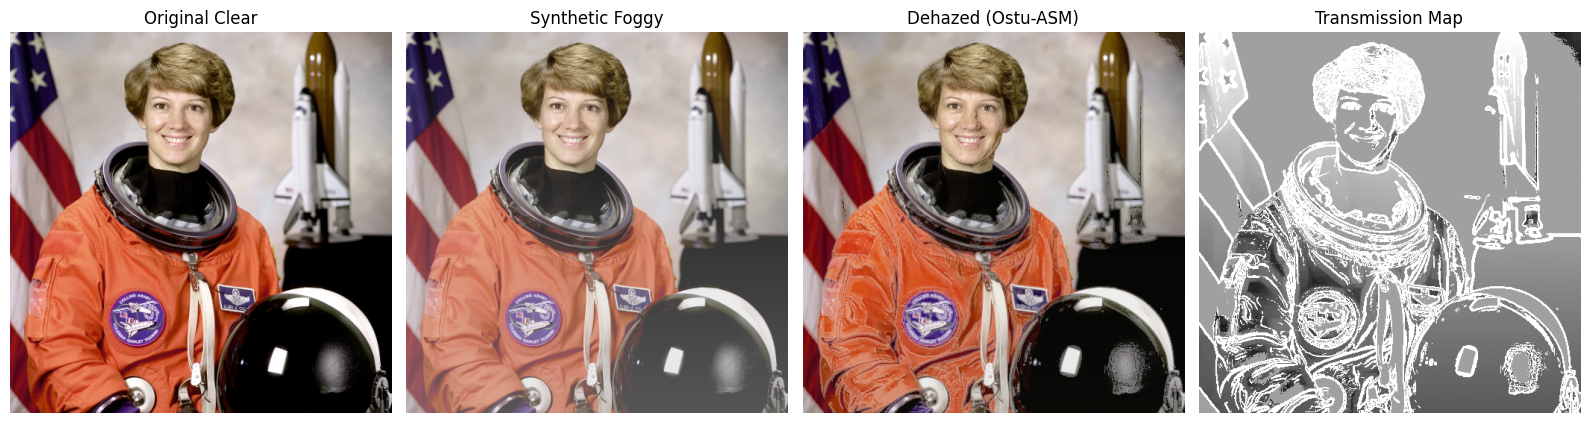

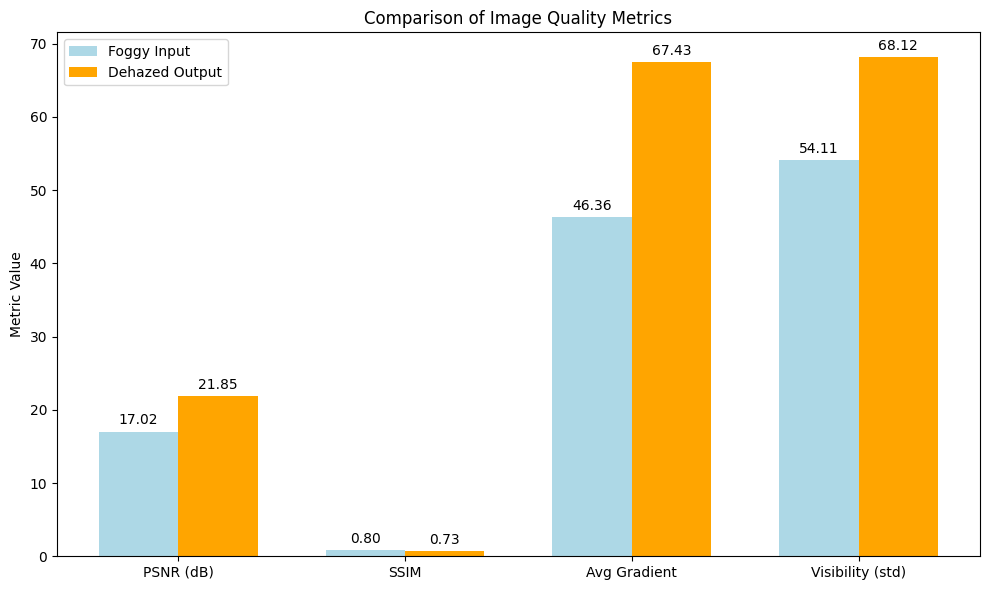

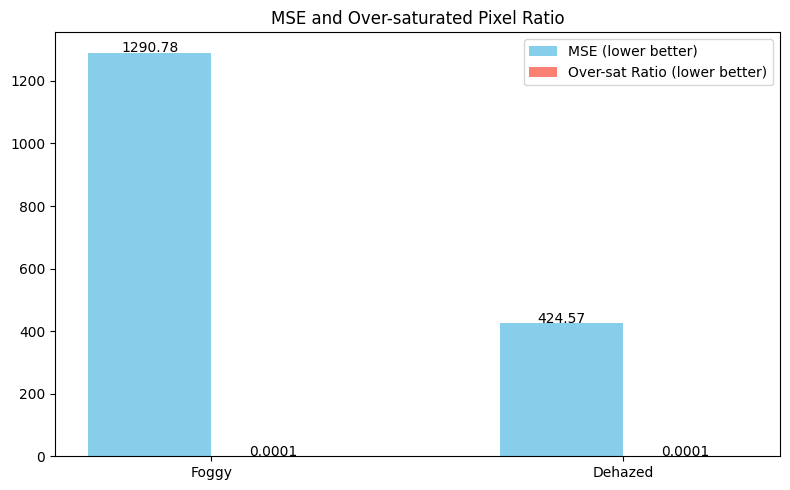


=== Evaluation Metrics Summary ===
Metric               Foggy Input     Dehazed Output 
--------------------------------------------------
MSE                  1290.7836       424.5728       
PSNR (dB)            17.0223         21.8513        
SSIM                 0.8012          0.7304         
Entropy (orig)       7.4536          7.4536         
Entropy (proc)       7.5842          7.5665         
Avg Gradient         46.3583         67.4266        
Visibility (std)     54.1139         68.1213        
Contrast             1.8149          2.1647         
Over-sat. Ratio      0.0001          0.0001         

Dehazed image saved as 'dehazed_output.jpg'


In [ ]:
# ============================================================
# Ostu-ASM Defogging + Comprehensive Evaluation Metrics
# IEEE ACCESS 2025 – Fully Self‑Contained for Colab
# ============================================================

import cv2
import numpy as np
from skimage import data, img_as_float
from skimage.filters import threshold_otsu
from skimage.metrics import structural_similarity as ssim
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Dark Channel Prior (DCP) utilities
# ------------------------------------------------------------------
def get_dark_channel(img, patch_size=15):
    b, g, r = cv2.split(img)
    min_ch = np.minimum(np.minimum(r, g), b).astype(np.float32)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch_size, patch_size))
    dark = cv2.erode(min_ch, kernel)
    return dark

def get_atmospheric_light(img, dark, top_percent=0.001):
    h, w = dark.shape
    num_pixels = max(1, int(h * w * top_percent))
    flat_dark = dark.flatten()
    indices = np.argsort(flat_dark)[-num_pixels:]
    flat_img = img.reshape(-1, 3).astype(np.float32)
    A = np.mean(flat_img[indices], axis=0)
    return A

def get_initial_transmission(img, A, omega=0.95, patch_size=15):
    img_f = img.astype(np.float32) / 255.0
    A_f = A / 255.0
    t = np.ones((img.shape[0], img.shape[1]), dtype=np.float32)
    for c in range(3):
        t = np.minimum(t, img_f[:, :, c] / (A_f[c] + 1e-6))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch_size, patch_size))
    t = cv2.erode(t, kernel)
    t = 1.0 - omega * t
    return t

# ------------------------------------------------------------------
# 2. Sky segmentation (Otsu-based)
# ------------------------------------------------------------------
def compute_sky_score(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    brightness = hsv[:, :, 2].astype(np.float32) / 255.0
    saturation = hsv[:, :, 1].astype(np.float32) / 255.0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    grad_mag = grad_mag / (grad_mag.max() + 1e-6)
    score = brightness * (1 - saturation) * (1 - grad_mag)
    return score

def segment_sky(img, score_map=None):
    if score_map is None:
        score_map = compute_sky_score(img)
    score_uint8 = (score_map * 255).astype(np.uint8)
    thresh = threshold_otsu(score_uint8)
    sky_mask = (score_uint8 >= thresh).astype(np.uint8) * 255
    return sky_mask

# ------------------------------------------------------------------
# 3. Pure-white region segmentation (equations 14–17)
# ------------------------------------------------------------------
def segment_pure_white(img, dark, A, tau=0.05, eps=0.05, gamma=0.6, win_size=15):
    A_mean = np.mean(A) / 255.0
    dark_norm = dark.astype(np.float32) / 255.0
    cond1 = np.abs(A_mean - dark_norm) < tau
    I_b = cond1.astype(np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    grad_mag = grad_mag / (grad_mag.max() + 1e-6)
    cond2 = grad_mag < eps
    G_b = cond2.astype(np.float32)
    kernel = np.ones((win_size, win_size), np.float32) / (win_size * win_size)
    avg_I_b = cv2.filter2D(I_b, -1, kernel)
    I_f = avg_I_b - I_b + (1.0 - avg_I_b) * G_b
    I_w = (I_f < gamma).astype(np.uint8) * 255
    return I_w

# ------------------------------------------------------------------
# 4. Transmission refinement for pure-white regions (eq. 18)
# ------------------------------------------------------------------
def refine_transmission_for_white(t, mask_pure_white, win_size=15):
    kernel = np.ones((win_size, win_size), np.float32) / (win_size * win_size)
    t_avg = cv2.filter2D(t, -1, kernel)
    mask = mask_pure_white.astype(np.float32) / 255.0
    t_refined = t + mask * t_avg
    t_refined = np.clip(t_refined, 0.1, 1.0)
    return t_refined

# ------------------------------------------------------------------
# 5. Main defogging pipeline (Ostu-ASM)
# ------------------------------------------------------------------
def defog_ostu_asm(img, omega=0.95, patch_size=15, tau=0.05, eps=0.05, t0=0.1):
    dark = get_dark_channel(img, patch_size)
    A = get_atmospheric_light(img, dark)
    t = get_initial_transmission(img, A, omega, patch_size)
    sky_mask = segment_sky(img)
    non_sky_mask = cv2.bitwise_not(sky_mask)
    pw_mask = segment_pure_white(img, dark, A, tau, eps)
    pw_mask = cv2.bitwise_and(pw_mask, non_sky_mask)
    t_refined = refine_transmission_for_white(t, pw_mask, patch_size)
    sky_mask_float = sky_mask.astype(np.float32) / 255.0
    t_sky = 0.8 * np.ones_like(t)
    t_final = t_refined * (1.0 - sky_mask_float) + t_sky * sky_mask_float
    t_final = np.clip(t_final, 0.1, 1.0)
    img_f = img.astype(np.float32) / 255.0
    A_f = A / 255.0
    J = np.zeros_like(img_f)
    for c in range(3):
        J[:, :, c] = (img_f[:, :, c] - A_f[c]) / np.maximum(t_final, t0) + A_f[c]
    J = np.clip(J, 0, 1)
    J = (J * 255).astype(np.uint8)
    return J, t_final, sky_mask, pw_mask

# ------------------------------------------------------------------
# 6. Evaluation metrics
# ------------------------------------------------------------------
def compute_metrics(original, processed):
    """
    Compute a set of image quality metrics.
    original, processed: uint8 images (BGR or RGB) – same size.
    Returns dict of metrics.
    """
    # Convert to grayscale for some metrics
    if len(original.shape) == 3:
        orig_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
        proc_gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)
    else:
        orig_gray = original
        proc_gray = processed

    # MSE
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)

    # PSNR
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 10 * np.log10(255.0 ** 2 / mse)

    # SSIM (on grayscale, for simplicity)
    ssim_val = ssim(orig_gray, proc_gray, data_range=255)

    # Entropy (Shannon) on grayscale
    ent_orig = shannon_entropy(orig_gray)
    ent_proc = shannon_entropy(proc_gray)

    # Average gradient (mean of gradient magnitude) – measure of sharpness
    grad_x = cv2.Sobel(proc_gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(proc_gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    avg_grad = np.mean(grad_mag)

    # Visibility: RMS contrast (std of intensity)
    visibility = np.std(proc_gray)

    # Visual contrast: another measure (maybe max-min)/mean
    contrast = (np.max(proc_gray) - np.min(proc_gray)) / (np.mean(proc_gray) + 1e-6)

    # Over-saturated pixels: any channel > 250 (or > 0.98 normalized)
    oversat = np.sum(np.any(processed > 250, axis=2)) / (processed.shape[0] * processed.shape[1])

    metrics = {
        'MSE': mse,
        'PSNR (dB)': psnr,
        'SSIM': ssim_val,
        'Entropy (orig)': ent_orig,
        'Entropy (proc)': ent_proc,
        'Avg Gradient': avg_grad,
        'Visibility (std)': visibility,
        'Contrast': contrast,
        'Over-sat. Ratio': oversat
    }
    return metrics

# ------------------------------------------------------------------
# 7. Generate synthetic foggy image from a built-in clear image
# ------------------------------------------------------------------
def create_synthetic_fog(clear_img, fog_density=0.6):
    h, w = clear_img.shape[:2]
    depth = np.linspace(0, 1, h).reshape(h, 1)
    depth = np.tile(depth, (1, w))
    beta = 0.8 * fog_density
    t = np.exp(-beta * depth)
    A = np.array([200, 200, 200], dtype=np.float32)
    foggy = clear_img.astype(np.float32) * t[:, :, np.newaxis] + A * (1 - t[:, :, np.newaxis])
    foggy = np.clip(foggy, 0, 255).astype(np.uint8)
    return foggy, t

# ==================================================================
# MAIN EXECUTION
# ==================================================================
if __name__ == "__main__":
    # 1. Load a sample clear image
    clear_img_rgb = data.astronaut()   # RGB
    clear_img = cv2.cvtColor(clear_img_rgb, cv2.COLOR_RGB2BGR)  # convert to BGR for OpenCV

    # 2. Create synthetic fog
    foggy_img, true_t = create_synthetic_fog(clear_img, fog_density=0.7)

    # 3. Run defogging
    dehazed, t_est, sky_mask, pw_mask = defog_ostu_asm(foggy_img)

    # 4. Compute metrics for foggy and dehazed (compared to clear)
    metrics_foggy = compute_metrics(clear_img, foggy_img)
    metrics_dehazed = compute_metrics(clear_img, dehazed)

    # 5. Display images
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 4, 1); plt.imshow(cv2.cvtColor(clear_img, cv2.COLOR_BGR2RGB)); plt.title('Original Clear'); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(cv2.cvtColor(foggy_img, cv2.COLOR_BGR2RGB)); plt.title('Synthetic Foggy'); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(cv2.cvtColor(dehazed, cv2.COLOR_BGR2RGB)); plt.title('Dehazed (Ostu-ASM)'); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(t_est, cmap='gray'); plt.title('Transmission Map'); plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 6. Bar chart comparison of key metrics
    # Select metrics to plot
    keys = ['PSNR (dB)', 'SSIM', 'Avg Gradient', 'Visibility (std)']
    foggy_vals = [metrics_foggy[k] for k in keys]
    dehazed_vals = [metrics_dehazed[k] for k in keys]

    # Also MSE (lower is better) – we'll plot separately or invert
    # For MSE, we can plot 1/(MSE+1) or just show as a table.
    # We'll create a grouped bar chart for the above metrics.

    x = np.arange(len(keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, foggy_vals, width, label='Foggy Input', color='lightblue')
    bars2 = ax.bar(x + width/2, dehazed_vals, width, label='Dehazed Output', color='orange')

    ax.set_ylabel('Metric Value')
    ax.set_title('Comparison of Image Quality Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(keys)
    ax.legend()

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # 7. Additional metrics: MSE and Over-sat (separate bar chart)
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    mse_vals = [metrics_foggy['MSE'], metrics_dehazed['MSE']]
    oversat_vals = [metrics_foggy['Over-sat. Ratio'], metrics_dehazed['Over-sat. Ratio']]
    x2 = np.arange(2)
    width2 = 0.3
    ax2.bar(x2 - width2/2, mse_vals, width2, label='MSE (lower better)', color='skyblue')
    ax2.bar(x2 + width2/2, oversat_vals, width2, label='Over-sat Ratio (lower better)', color='salmon')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(['Foggy', 'Dehazed'])
    ax2.set_title('MSE and Over-saturated Pixel Ratio')
    ax2.legend()
    for i, v in enumerate(mse_vals):
        ax2.text(i - width2/2, v + 0.5, f'{v:.2f}', ha='center')
    for i, v in enumerate(oversat_vals):
        ax2.text(i + width2/2, v + 0.005, f'{v:.4f}', ha='center')
    plt.tight_layout()
    plt.show()

    # 8. Print a summary table
    print("\n=== Evaluation Metrics Summary ===")
    print(f"{'Metric':<20} {'Foggy Input':<15} {'Dehazed Output':<15}")
    print("-" * 50)
    for key in metrics_foggy.keys():
        print(f"{key:<20} {metrics_foggy[key]:<15.4f} {metrics_dehazed[key]:<15.4f}")

    # 9. Save dehazed image
    cv2.imwrite('dehazed_output.jpg', dehazed)
    print("\nDehazed image saved as 'dehazed_output.jpg'")